# Neuron

#### Import bibliotek

In [153]:
from sklearn.datasets import make_classification, make_moons
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

#### Funkcje do oceny skuteczności 

In [154]:
def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()
    
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
        
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()


### Wygenerowanie danych

make_classification

x (2599, 2)
y (2599,)


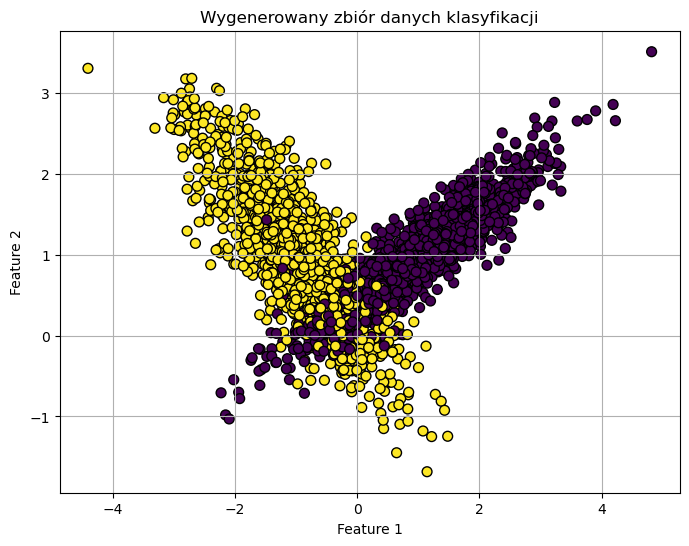

In [155]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])
X_classification, y_classification = make_classification(
    n_samples=my_n_samples, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    random_state=my_index,
)

print('x', X_classification.shape)
print('y', y_classification.shape)
plot_dataset(X_classification, y_classification, title="Wygenerowany zbiór danych klasyfikacji")

make_moons

X_moons (2599, 2)
y_moons (2599,)


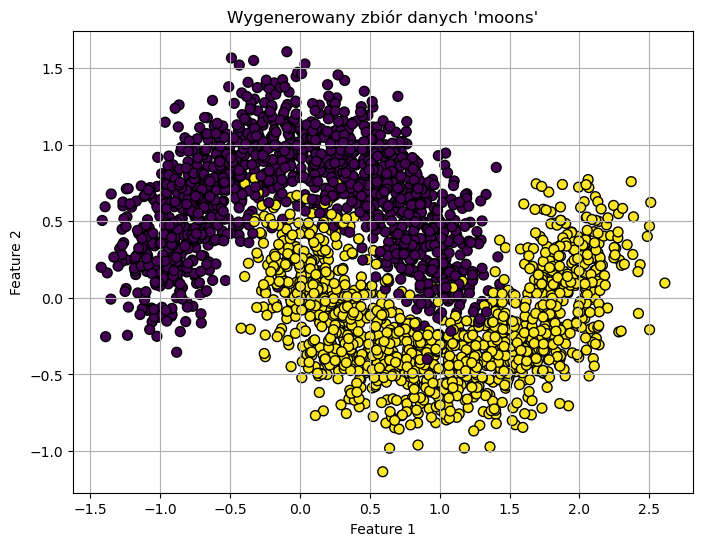

In [156]:
X_moons, y_moons = make_moons(n_samples=my_n_samples, noise=0.2, random_state=my_index)

print('X_moons', X_moons.shape)
print('y_moons', y_moons.shape)
plot_dataset(X_moons, y_moons, title="Wygenerowany zbiór danych 'moons'")

#### Podział danych na treningowe i testowe

In [157]:
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=my_index
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=my_index
)

print("classification:", X_classification_train.shape, y_classification_train.shape, X_classification_test.shape, y_classification_test.shape)
print("nmoons:", X_moons_train.shape, y_moons_train.shape, X_moons_test.shape, y_moons_test.shape)

classification: (2079, 2) (2079,) (520, 2) (520,)
nmoons: (2079, 2) (2079,) (520, 2) (520,)


### Własna implementacja neuronu

In [158]:
class MyNeuron:
    def __init__(self, 
                 activation='sigmoid',
                 eta_min=0.05, 
                 eta_max=0.05,
                 n_epochs=200, 
                 tol=0.0001,
                 batch_size=1
                 ):
        self.w = None
        self.bias = None
        self.activation_name = activation
        self.eta_min = eta_min
        self.eta_max = eta_max
        self.n_epochs = n_epochs
        self.tol = tol
        self.batch_size = batch_size

    def _initialize_weights(self, n_features):
        if self.w is None:
            self.w = np.random.randn(n_features) * 0.01
        if self.bias is None:
            self.bias = np.random.randn() * 0.01

    def _activation(self, x):
        if self.activation_name == "sigmoid":
            return 1 / (1 + np.exp(-x))
        elif self.activation_name == "heaviside":
            return np.where(x >= 0, 1.0, 0.0)
        elif self.activation_name == "tanh":
            return np.tanh(x)
        elif self.activation_name == "relu":
            return np.maximum(0, x)
        elif self.activation_name == "leaky_relu":
            return np.where(x > 0, x, 0.01 * x)
        elif self.activation_name == "sin":
            return np.sin(x)
        elif self.activation_name == "sign":
            return np.sign(x)

    def _activation_derivative(self, x):
        if self.activation_name == "sigmoid":
            s = 1 / (1 + np.exp(-x))
            return s * (1 - s)
        elif self.activation_name == "heaviside":
            return np.zeros_like(x)
        elif self.activation_name == "tanh":
            return 1 - np.tanh(x) ** 2
        elif self.activation_name == "relu":
            return (x > 0).astype(float)
        elif self.activation_name == "leaky_relu":
            return np.where(x > 0, 1.0, 0.01)
        elif self.activation_name == "sin":
            return np.cos(x)
        elif self.activation_name == "sign":
            return np.zeros_like(x)
   
    def _cosine_annealing(self, epoch):
        return self.eta_min + 0.5 * (self.eta_max - self.eta_min) * (1 + np.cos(np.pi * epoch / self.n_epochs))

    def predict(self, X, threshold=0.5):
        return (self._activation(X @ self.w + self.bias) > threshold).astype(int)

    def train(self, X, y):
        self._initialize_weights(X.shape[1])

        for epoch in range(self.n_epochs):
            eta = self._cosine_annealing(epoch) if self.eta_min != self.eta_max else self.eta_max
            indices = np.random.permutation(len(X))
            X, y = X[indices], y[indices]

            for i in range(0, len(X), self.batch_size):
                X_batch = X[i:i+self.batch_size]
                y_batch = y[i:i+self.batch_size]

                s = X_batch @ self.w + self.bias
                y_pred = self._activation(s)
                error = y_batch - y_pred
                delta = (error * self._activation_derivative(s)).reshape(-1, 1) * X_batch

                dw = delta.mean(axis=0)
                self.w += eta * dw

                self.bias += eta * error.mean()

            if np.linalg.norm(dw) < self.tol:
                break


### Uczenie i ewaluacja pojedynczego neuronu z **logistyczną** funkcją aktywacji

make_classification
Accuracy: 0.898, Sensitivity: 0.935, Specificity: 0.861


<Figure size 600x600 with 0 Axes>

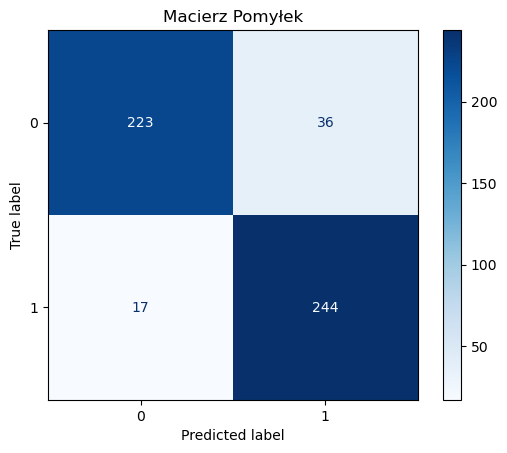

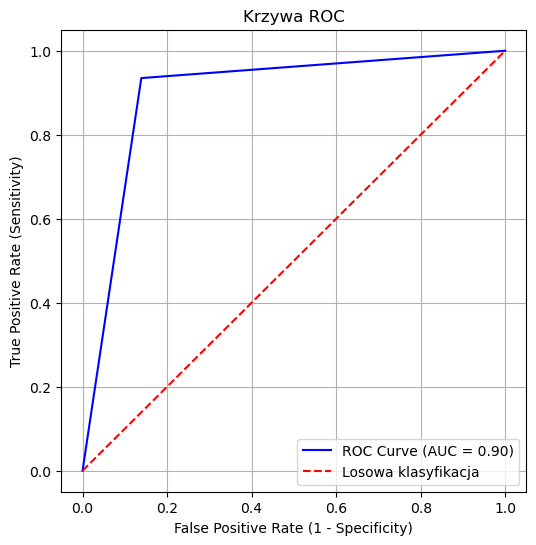

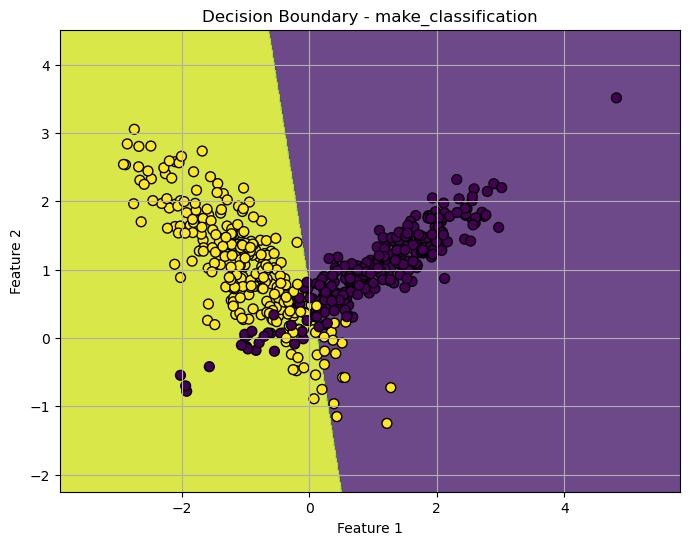

make_moons
Accuracy: 0.879, Sensitivity: 0.922, Specificity: 0.837


<Figure size 600x600 with 0 Axes>

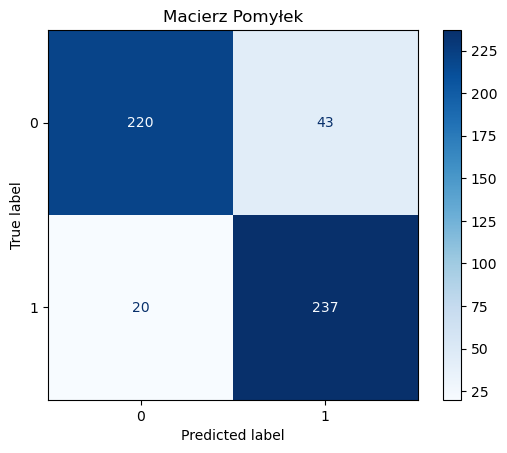

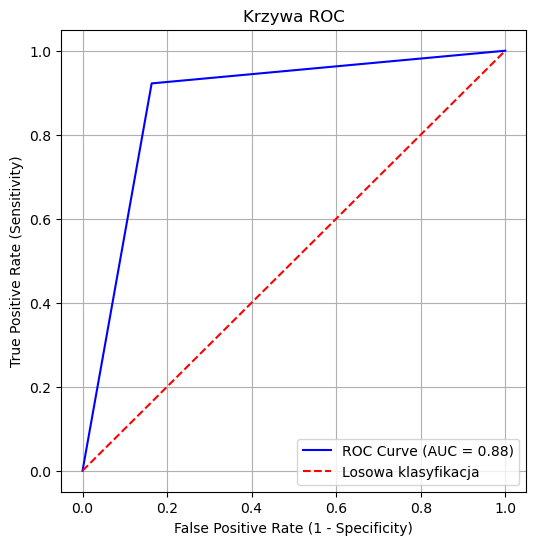

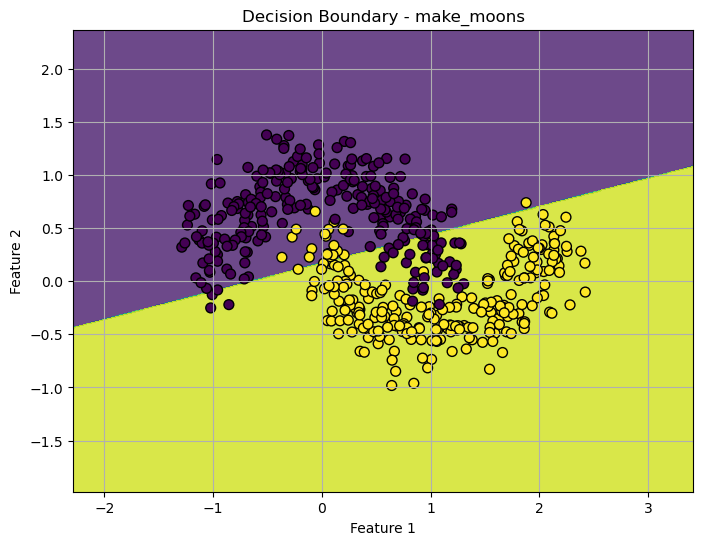

In [159]:
results = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='sigmoid')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test)

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision Boundary - make_classification")
results.loc["make_classification - sigmoid"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='sigmoid')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test)

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision Boundary - make_moons")
results.loc["make_moons - sigmoid"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [160]:
pd.DataFrame(results)

,Accuracy,Sensitivity,Specificity
make_classification - sigmoid,0.898077,0.934866,0.861004
make_moons - sigmoid,0.878846,0.922179,0.836502


### Uczenie i ewaluacja pojedynczego neuronu z **Heaviside**

make_classification
Accuracy: 0.529, Sensitivity: 1.000, Specificity: 0.054


<Figure size 600x600 with 0 Axes>

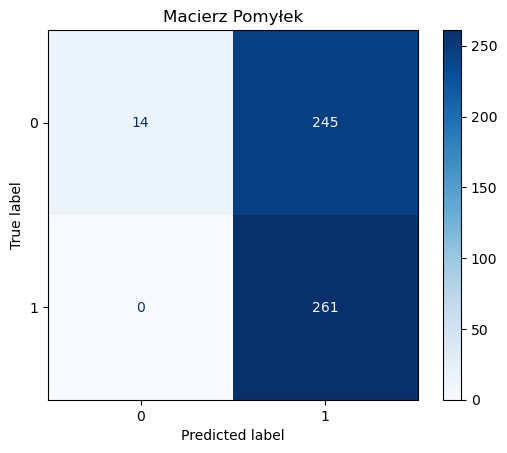

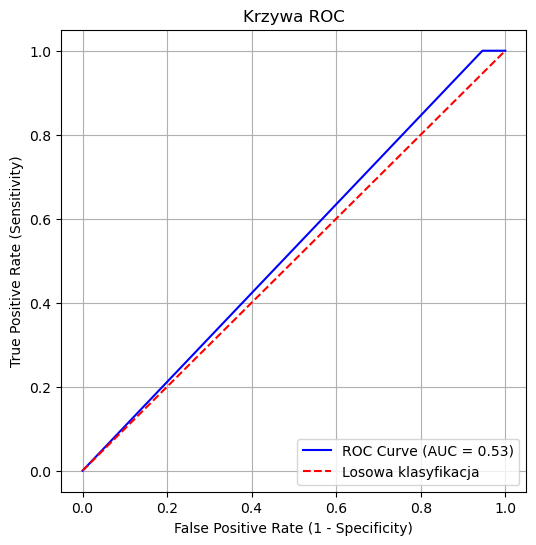

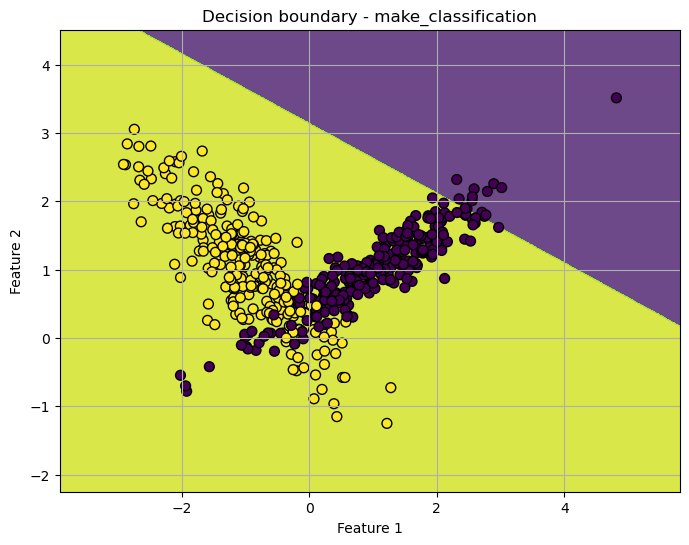

make_moons
Accuracy: 0.506, Sensitivity: 0.000, Specificity: 1.000


<Figure size 600x600 with 0 Axes>

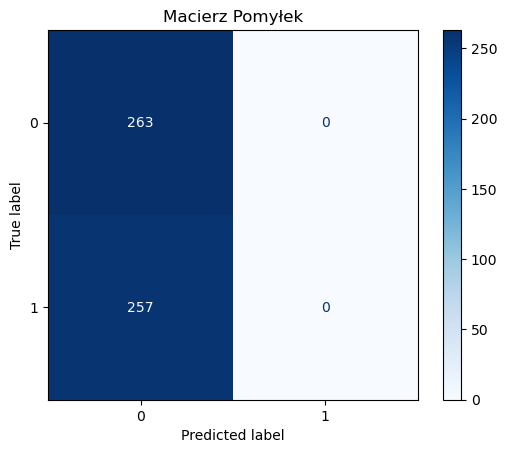

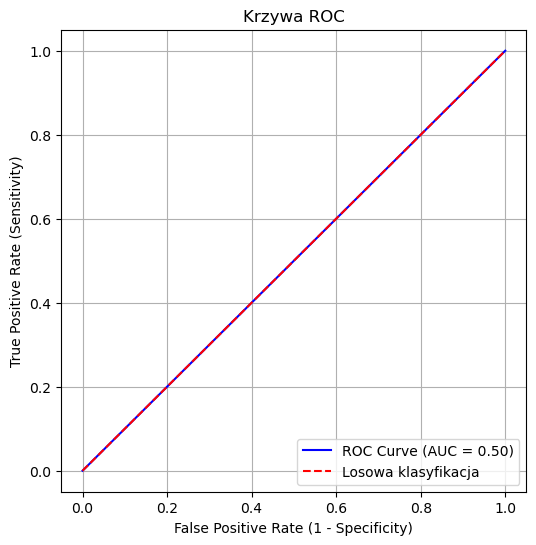

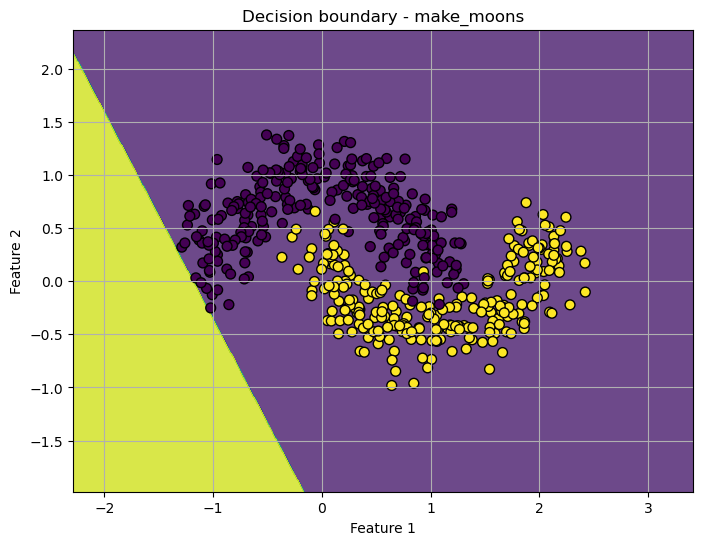

In [161]:
results_heaviside = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='heaviside')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test)

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision boundary - make_classification")
results_heaviside.loc["make_classification - heaviside"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='heaviside')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test)

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision boundary - make_moons")
results_heaviside.loc["make_moons - heaviside"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [162]:
results = pd.concat([results, results_heaviside])
pd.DataFrame(results_heaviside)

,Accuracy,Sensitivity,Specificity
make_classification - heaviside,0.528846,1.0,0.054054
make_moons - heaviside,0.505769,0.0,1.000000


### Uczenie i ewaluacja pojedynczego neuronu z **sin**

make_classification
Accuracy: 0.856, Sensitivity: 0.981, Specificity: 0.730


<Figure size 600x600 with 0 Axes>

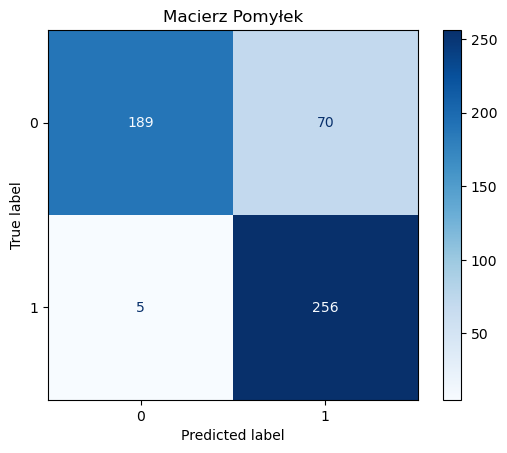

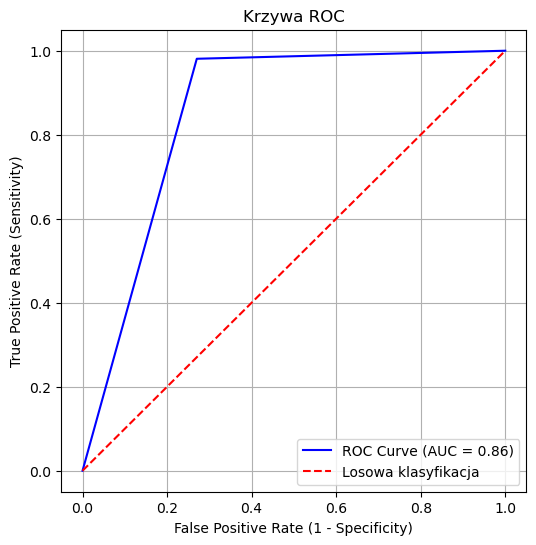

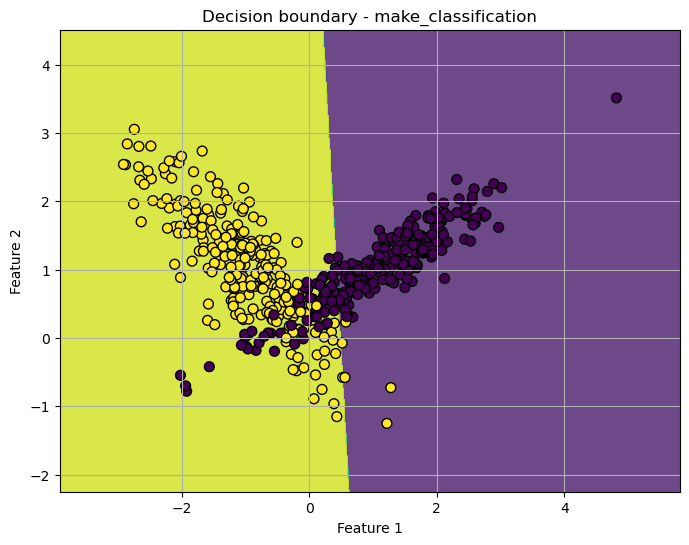

make_moons
Accuracy: 0.840, Sensitivity: 0.957, Specificity: 0.726


<Figure size 600x600 with 0 Axes>

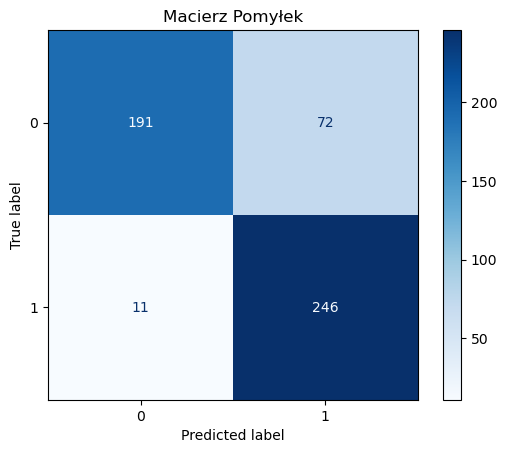

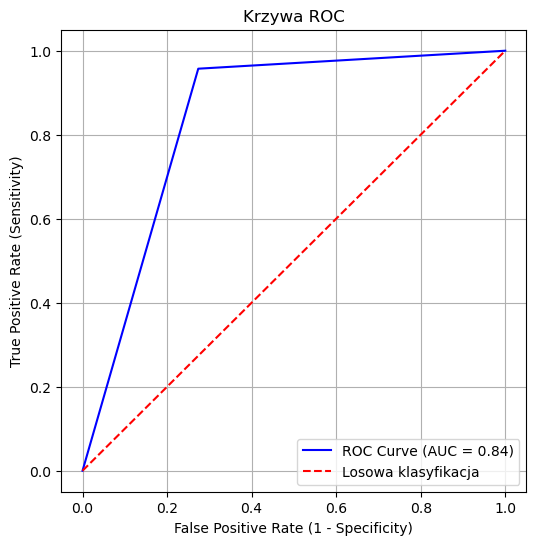

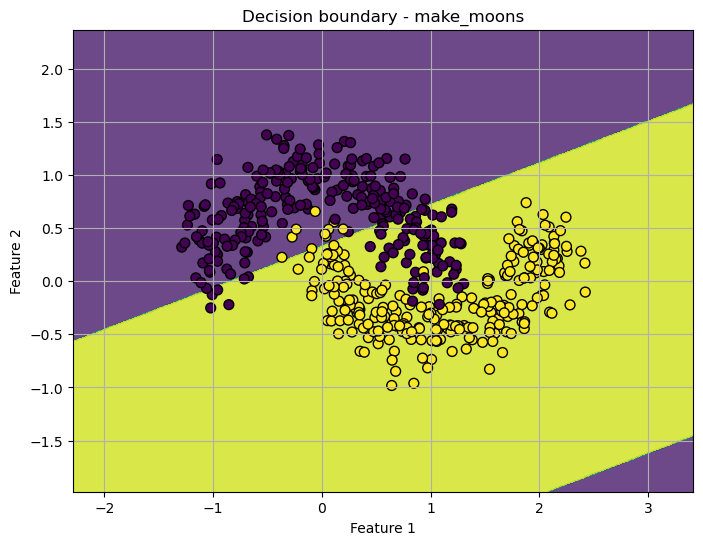

In [163]:
results_sin = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='sin')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test) 

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision boundary - make_classification")
results_sin.loc["make_classification - sin"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='sin')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test) 

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision boundary - make_moons")
results_sin.loc["make_moons - sin"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [164]:
results = pd.concat([results, results_sin])
pd.DataFrame(results_sin)

,Accuracy,Sensitivity,Specificity
make_classification - sin,0.855769,0.980843,0.729730
make_moons - sin,0.840385,0.957198,0.726236


### Uczenie i ewaluacja pojedynczego neuronu z **tanh**

make_classification
Accuracy: 0.850, Sensitivity: 0.985, Specificity: 0.714


<Figure size 600x600 with 0 Axes>

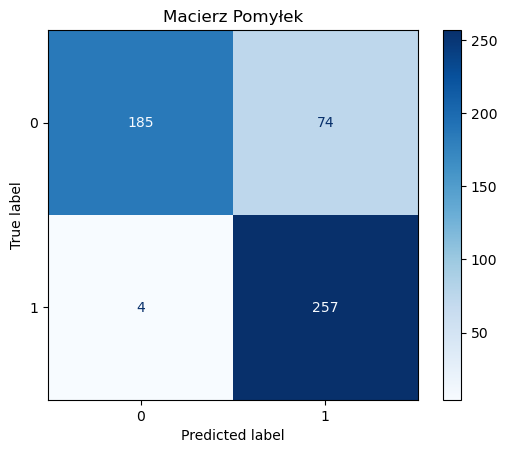

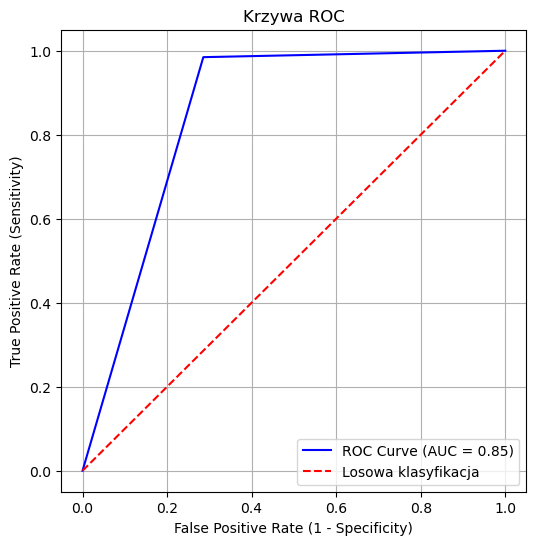

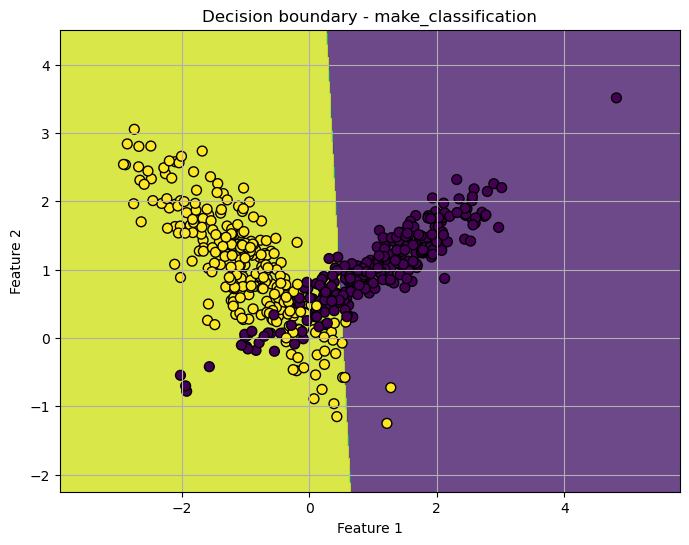

make_moons
Accuracy: 0.858, Sensitivity: 0.953, Specificity: 0.764


<Figure size 600x600 with 0 Axes>

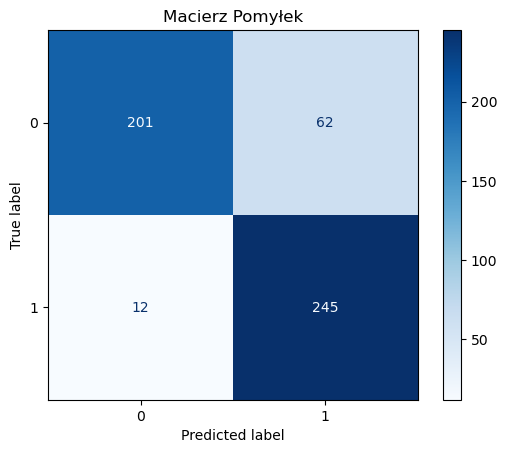

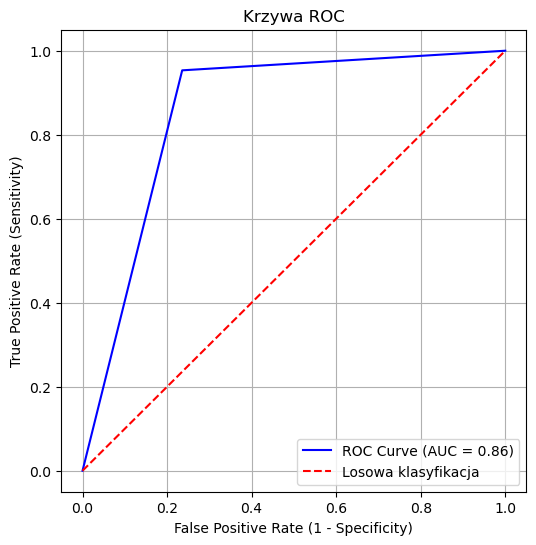

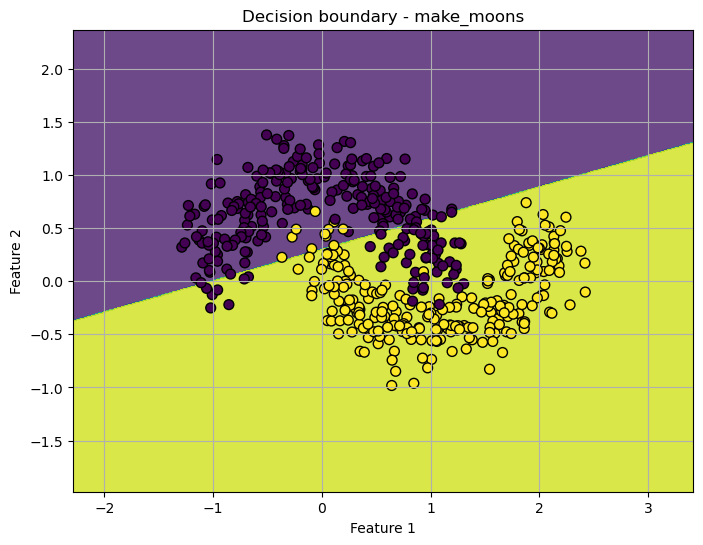

In [165]:
results_tanh = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='tanh')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test)

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision boundary - make_classification")
results_tanh.loc["make_classification - tanh"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='tanh')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test)

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision boundary - make_moons")
results_tanh.loc["make_moons - tanh"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [166]:
results = pd.concat([results, results_tanh])
pd.DataFrame(results_tanh)

,Accuracy,Sensitivity,Specificity
make_classification - tanh,0.850000,0.984674,0.714286
make_moons - tanh,0.857692,0.953307,0.764259


### Uczenie i ewaluacja pojedynczego neuronu z **sign**

make_classification
Accuracy: 0.502, Sensitivity: 1.000, Specificity: 0.000


<Figure size 600x600 with 0 Axes>

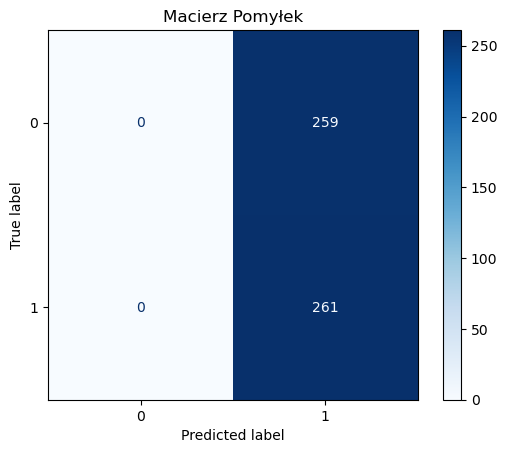

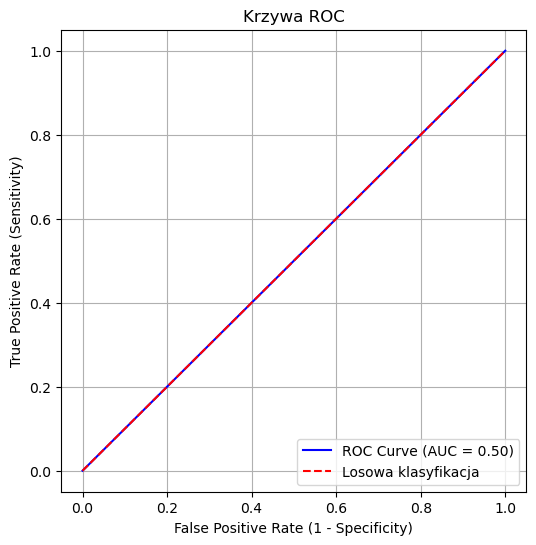

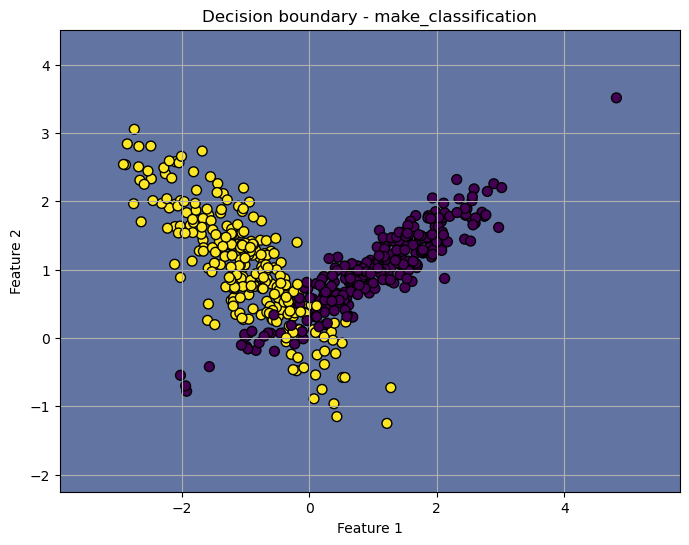

make_moons
Accuracy: 0.365, Sensitivity: 0.000, Specificity: 0.722


<Figure size 600x600 with 0 Axes>

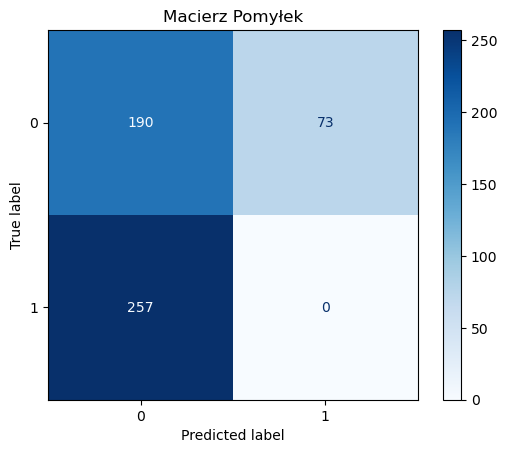

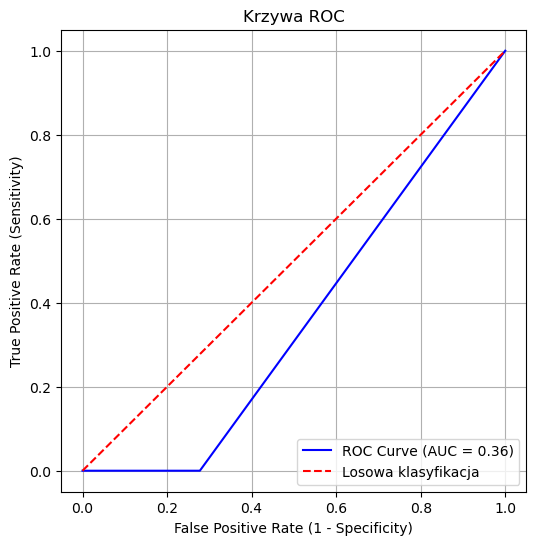

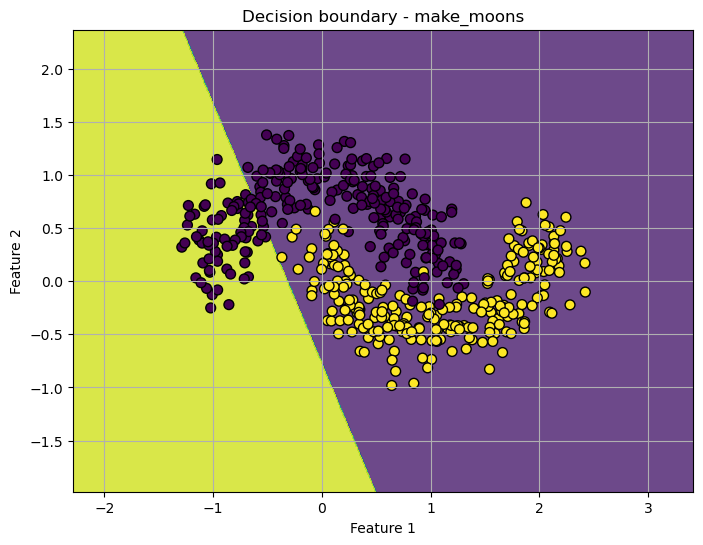

In [167]:
results_sign = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='sign')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test)

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision boundary - make_classification")
results_sign.loc["make_classification - sign"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='sign')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test)

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision boundary - make_moons")
results_sign.loc["make_moons - sign"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [168]:
results = pd.concat([results, results_sign])
pd.DataFrame(results_sign)

,Accuracy,Sensitivity,Specificity
make_classification - sign,0.501923,1.0,0.000000
make_moons - sign,0.365385,0.0,0.722433


### Uczenie i ewaluacja pojedynczego neuronu z **ReLu**

make_classification
Accuracy: 0.892, Sensitivity: 0.943, Specificity: 0.842


<Figure size 600x600 with 0 Axes>

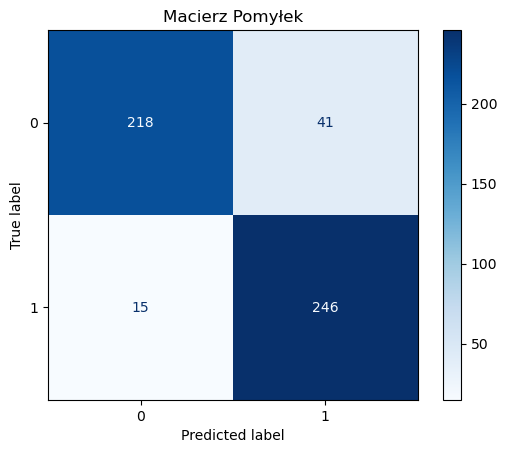

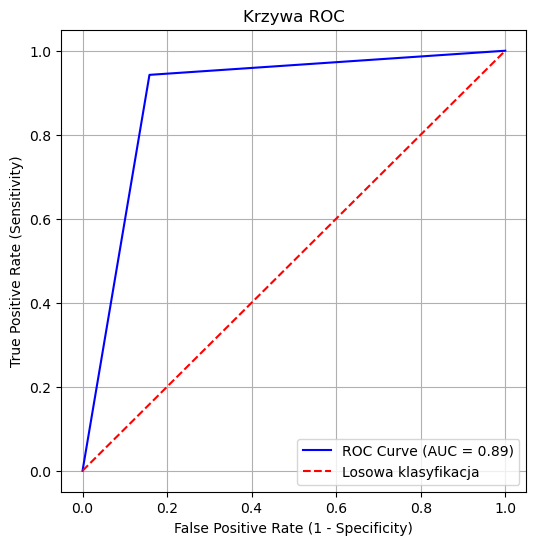

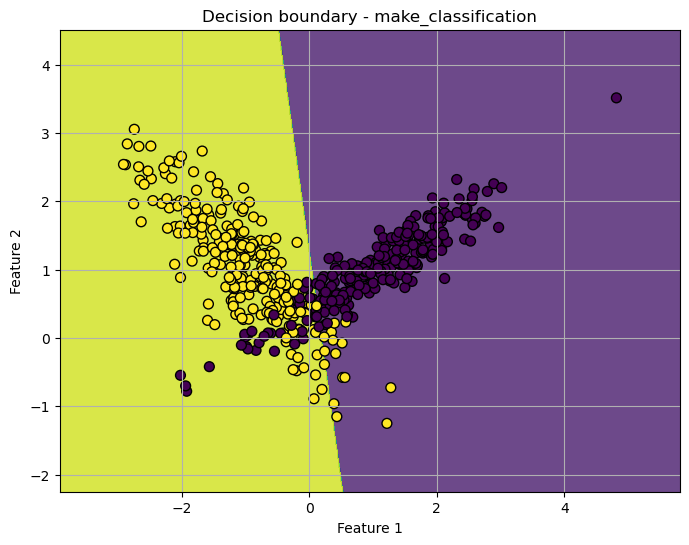

make_moons
Accuracy: 0.881, Sensitivity: 0.875, Specificity: 0.886


<Figure size 600x600 with 0 Axes>

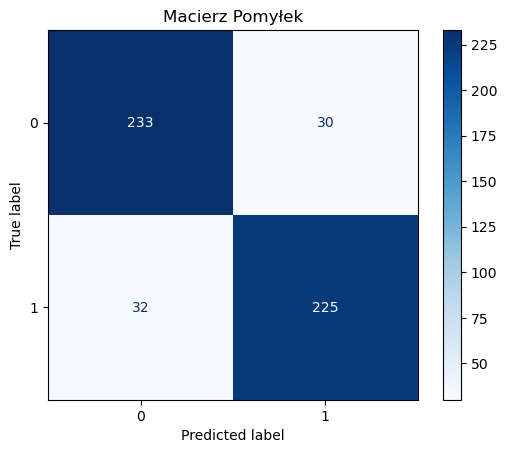

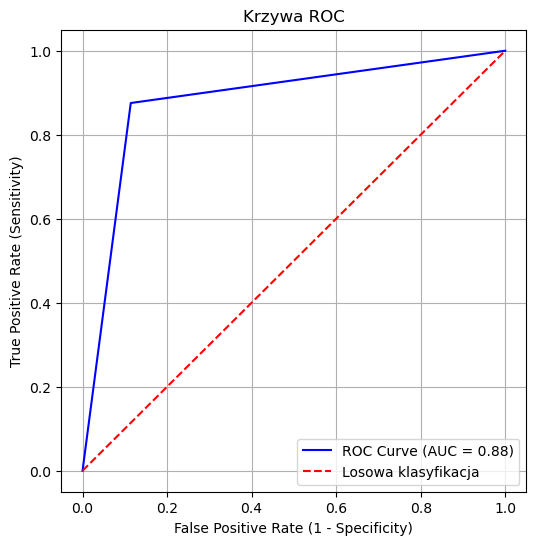

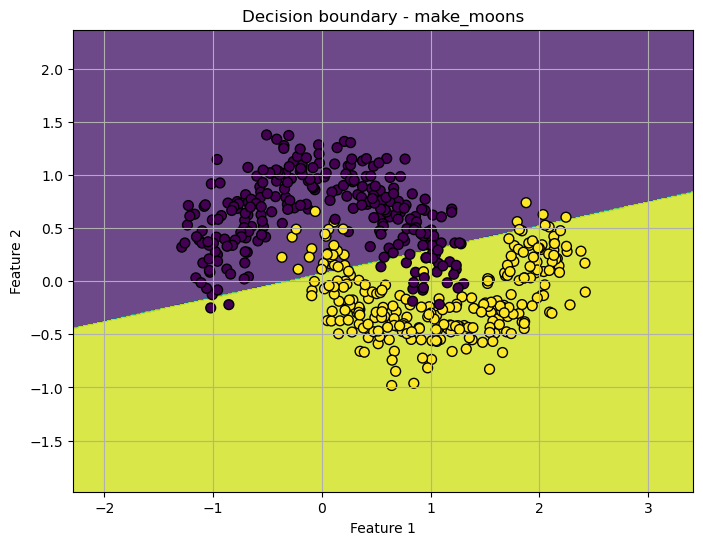

In [169]:
results_relu = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='relu')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test)

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision boundary - make_classification")
results_relu.loc["make_classification - relu"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='relu')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test)

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision boundary - make_moons")
results_relu.loc["make_moons - relu"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [170]:
results = pd.concat([results, results_relu])
pd.DataFrame(results_relu)

,Accuracy,Sensitivity,Specificity
make_classification - relu,0.892308,0.942529,0.841699
make_moons - relu,0.880769,0.875486,0.885932


### Uczenie i ewaluacja pojedynczego neuronu z **leaky ReLu**

make_classification
Accuracy: 0.894, Sensitivity: 0.946, Specificity: 0.842


<Figure size 600x600 with 0 Axes>

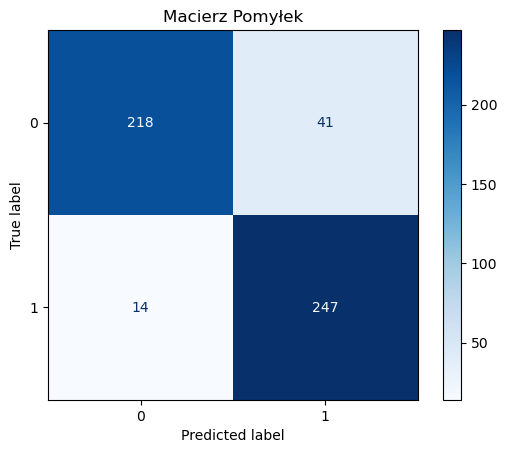

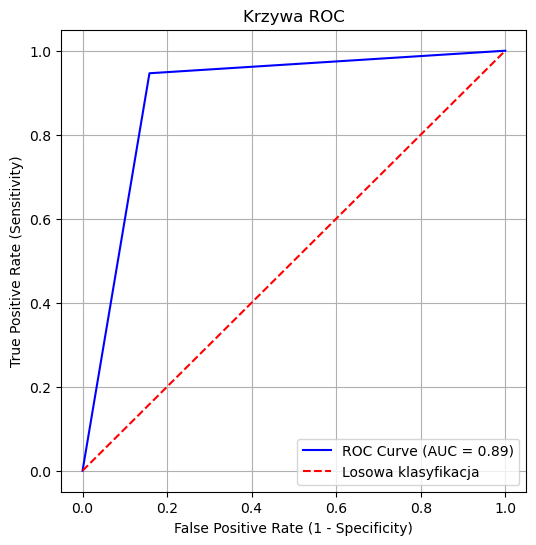

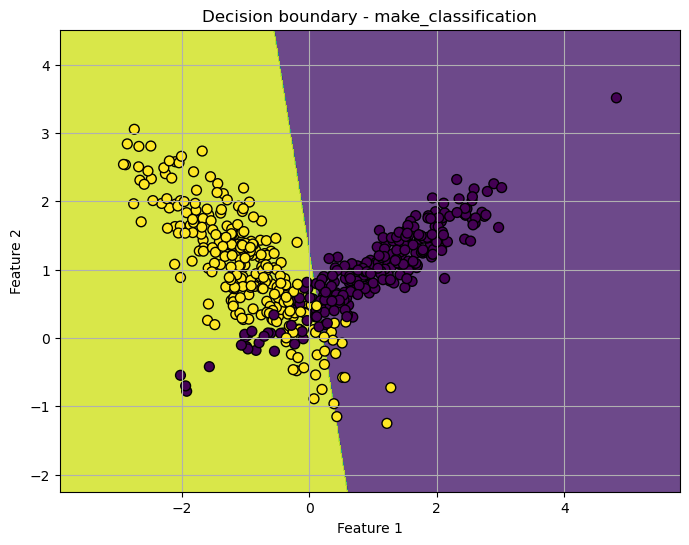

make_moons
Accuracy: 0.885, Sensitivity: 0.883, Specificity: 0.886


<Figure size 600x600 with 0 Axes>

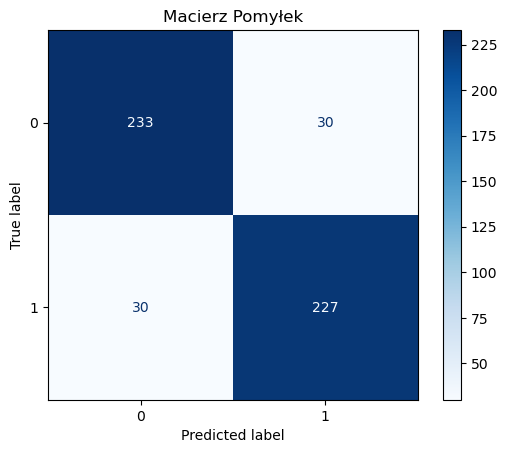

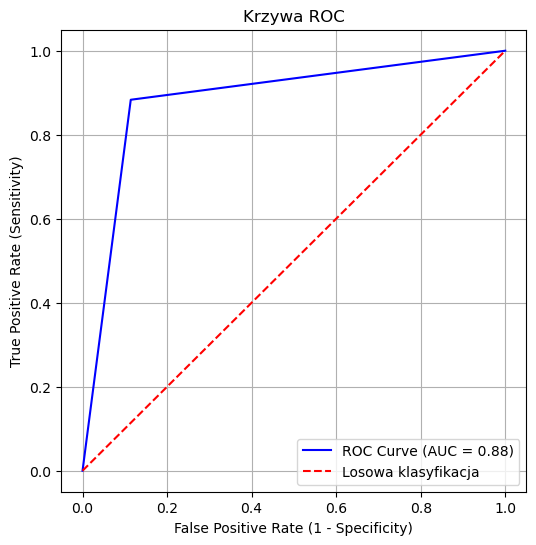

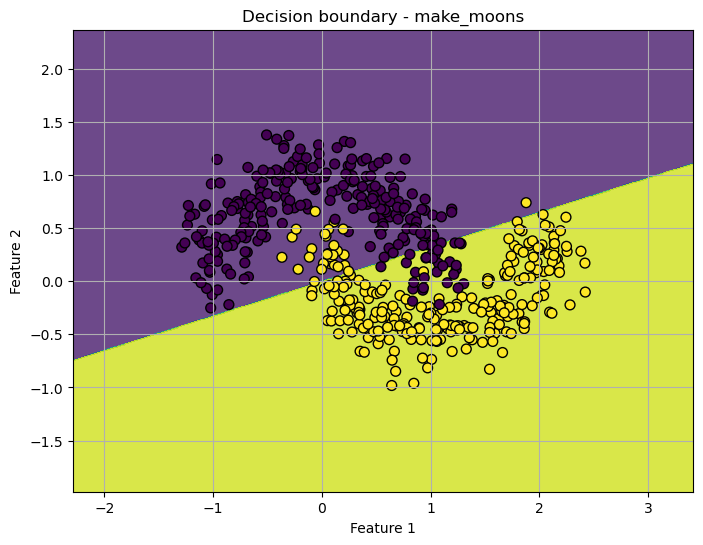

In [171]:
results_leaky_relu = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

neuron = MyNeuron(activation='leaky_relu')
neuron.train(X_classification_train, y_classification_train)
y_pred_test = neuron.predict(X_classification_test)

print("make_classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_test)
print(f"Accuracy: {accuracy:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")
plot_confusion_matrix(y_classification_test, y_pred_test, labels=[0, 1])
plot_roc_curve(y_classification_test, y_pred_test)
plot_decision_boundary(neuron, X_classification_test, y_classification_test, title="Decision boundary - make_classification")
results_leaky_relu.loc["make_classification - leaky_relu"] = [accuracy, sensitivity, specificity]

neuron_moons = MyNeuron(activation='leaky_relu')
neuron_moons.train(X_moons_train, y_moons_train)
y_pred_moons_test = neuron_moons.predict(X_moons_test)

print("make_moons")
accuracy_moons, sensitivity_moons, specificity_moons = calculate_metrics(y_moons_test, y_pred_moons_test)
print(f"Accuracy: {accuracy_moons:.3f}, Sensitivity: {sensitivity_moons:.3f}, Specificity: {specificity_moons:.3f}")
plot_confusion_matrix(y_moons_test, y_pred_moons_test, labels=[0, 1])
plot_roc_curve(y_moons_test, y_pred_moons_test)
plot_decision_boundary(neuron_moons, X_moons_test, y_moons_test, title="Decision boundary - make_moons")
results_leaky_relu.loc["make_moons - leaky_relu"] = [accuracy_moons, sensitivity_moons, specificity_moons]

In [172]:
results = pd.concat([results, results_leaky_relu])
pd.DataFrame(results_leaky_relu)

,Accuracy,Sensitivity,Specificity
make_classification - leaky_relu,0.894231,0.946360,0.841699
make_moons - leaky_relu,0.884615,0.883268,0.885932


### Porównanie wszystkich wyników

In [173]:
pd.DataFrame(results)

,Accuracy,Sensitivity,Specificity
make_classification - sigmoid,0.898077,0.934866,0.861004
make_moons - sigmoid,0.878846,0.922179,0.836502
make_classification - heaviside,0.528846,1.000000,0.054054
make_moons - heaviside,0.505769,0.000000,1.000000
make_classification - sin,0.855769,0.980843,0.729730
make_moons - sin,0.840385,0.957198,0.726236
make_classification - tanh,0.850000,0.984674,0.714286
make_moons - tanh,0.857692,0.953307,0.764259
make_classification - sign,0.501923,1.000000,0.000000
make_moons - sign,0.365385,0.000000,0.722433


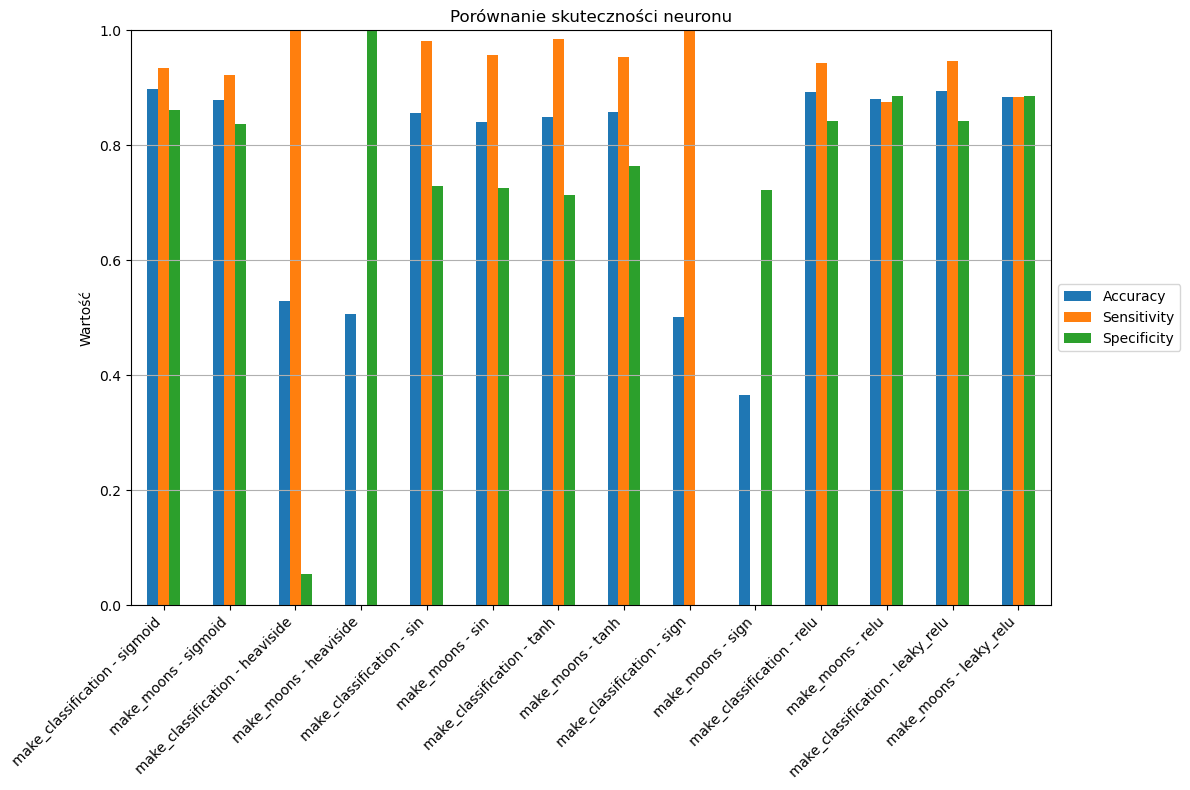

In [177]:
ax = results.plot(kind='bar', figsize=(12, 8))
plt.title("Porównanie skuteczności neuronu")
plt.ylabel("Wartość")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()